# import, paths

In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
from shapely.geometry import Point

# Set paths
desktop = Path.home() / "Desktop"
output_dir = Path(r"C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step")
output_dir.mkdir(parents=True, exist_ok=True)

print("Libraries imported and paths set")

Libraries imported and paths set


# default_refineries.gpkg

In [21]:
# Prepare default_refineries.gpkg
print("=" * 60)
print("Processing: default_refineries.gpkg")
print("=" * 60)

# Load refineries from desktop
refineries_path = desktop / "refineries_afrec_2020.gpkg"
print(f"\nLoading from: {refineries_path}")

gdf = gpd.read_file(refineries_path)
print(f"Loaded {len(gdf)} refineries")
print(f"Original columns: {gdf.columns.tolist()}")

# Step 1: Rename LPG_OUTPUT_TPY to LPG_prod and Refinery to name
if 'LPG_OUTPUT_TPY' in gdf.columns:
    gdf = gdf.rename(columns={'LPG_OUTPUT_TPY': 'LPG_prod'})
    print("✓ Renamed LPG_OUTPUT_TPY → LPG_prod")
if 'Refinery' in gdf.columns:
    gdf = gdf.rename(columns={'Refinery': 'name'})
    print("✓ Renamed Refinery → name")

# Step 2: Create geometry from lat/lon if they exist and geometry doesn't use them
if 'lat' in gdf.columns and 'lon' in gdf.columns:
    # Create Point geometry from lat/lon
    gdf['geometry'] = gdf.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
    print("✓ Created geometry from lat/lon coordinates")
    
    # Step 3: Remove lat and lon columns
    gdf = gdf.drop(columns=['lat', 'lon'])
    print("✓ Removed lat and lon fields")

# Ensure CRS is set
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
    print("✓ Set CRS to EPSG:4326")

# Save as default_refineries.gpkg
output_path = output_dir / "default_refineries.gpkg"
gdf.to_file(output_path, driver="GPKG")
print(f"\n✓ Saved to: {output_path}")
print(f"Final columns: {gdf.columns.tolist()}")
print(f"Final shape: {len(gdf)} records")

Processing: default_refineries.gpkg


NameError: name 'desktop' is not defined

# default_ports.gpkg

In [5]:
# Prepare default_ports.gpkg
print("\n" + "=" * 60)
print("Processing: default_ports.gpkg")
print("=" * 60)

# Load ports from Tesi_desk/africa_maritime_network
ports_path = desktop / "Tesi_desk" / "africa_maritime_network.gpkg"
print(f"\nLoading from: {ports_path}")

gdf = gpd.read_file(ports_path, layer="nodes_rank")
print(f"Loaded {len(gdf)} ports")
print(f"Original columns: {gdf.columns.tolist()}")

# Step 1: Remove lpg_compliance field if it exists
if 'lpg_compliance' in gdf.columns:
    gdf = gdf.drop(columns=['lpg_compliance'])
    print("✓ Removed lpg_compliance field")

# Step 2: Add VLGC_compliance boolean field based on LPG_max_draft
if 'LPG_max_draft' in gdf.columns:
    gdf['VLGC_compliance'] = pd.to_numeric(gdf['LPG_max_draft'], errors='coerce') > 13
    print("✓ Added VLGC_compliance field (True if LPG_max_draft > 13)")
else:
    gdf['VLGC_compliance'] = False
    print("⚠ LPG_max_draft not found, setting VLGC_compliance to False")

# Step 3: Delete specified fields
fields_to_delete = ['type', 'has_nearby_tank', 'draft_true', 'dwt_l_true', 'dwt_vl_true', 'length_true', 'infra']
existing_fields = [col for col in fields_to_delete if col in gdf.columns]
if existing_fields:
    gdf = gdf.drop(columns=existing_fields)
    print(f"✓ Deleted fields: {', '.join(existing_fields)}")

# Ensure CRS is set
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
    print("✓ Set CRS to EPSG:4326")

# Save as default_ports.gpkg
output_path = output_dir / "default_ports.gpkg"
gdf.to_file(output_path, driver="GPKG")
print(f"\n✓ Saved to: {output_path}")
print(f"Final columns: {gdf.columns.tolist()}")
print(f"Final shape: {len(gdf)} records")
print(f"VLGC_compliance distribution: True={gdf['VLGC_compliance'].sum()}, False={(~gdf['VLGC_compliance']).sum()}")


Processing: default_ports.gpkg

Loading from: C:\Users\Fra\Desktop\Tesi_desk\africa_maritime_network.gpkg
Loaded 118 ports
Original columns: ['id', 'name', 'fullname', 'infra', 'country', 'iso3', 'vessel_count_total', 'vessel_count_container', 'vessel_count_drybulk', 'vessel_count_generalcargo', 'vessel_count_roro', 'vessel_count_tanker', 'industry_top1', 'industry_top2', 'industry_top3', 'share_country_maritime_import', 'share_country_maritime_export', 'call_container', 'call_drybulk', 'call_generalcargo', 'call_roro', 'call_tanker', 'capacity_container_tons', 'capacity_drybulk_tons', 'capacity_generalcargo_tons', 'capacity_roro_tons', 'capacity_tanker_tons', 'time_container_h', 'time_drybulk_h', 'time_generalcargo_h', 'time_roro_h', 'time_tanker_h', 'source', 'type', 'has_nearby_tank', 'LPG_berths', 'LPG_max_draft', 'LPG_max_length', 'LPG_max_DWT', 'draft_true', 'dwt_l_true', 'dwt_vl_true', 'length_true', 'lpg_compliance', 'geometry']
✓ Removed lpg_compliance field
✓ Added VLGC_comp

# default_primary_storage.gpkg

In [20]:
# Prepare default_primary_storage.gpkg
print("\n" + "=" * 60)
print("Processing: default_primary_storage.gpkg")
print("=" * 60)

# Load tank terminals from Tesi_desk
storage_path = desktop / "Tesi_desk" / "tank_terminal_postgmaps_147.gpkg"
print(f"\nLoading from: {storage_path}")

gdf = gpd.read_file(storage_path)
print(f"Loaded {len(gdf)} storage terminals")
print(f"Original columns: {gdf.columns.tolist()}")

# Step 1: Rename tank_capacity to LPG_capacity
if 'tank_capacity' in gdf.columns:
    gdf = gdf.rename(columns={'tank_capacity': 'LPG_capacity'})
    print("✓ Renamed tank_capacity → LPG_capacity")

# Step 2: Remove specified fields
fields_to_delete = ['harbour', 'port_1km', 'port_2km', 'port_3km', 'port_5km', 'port_10km', 'port_20km', 'inland', 'gmaps_opening_hours', 'gmaps_status']
existing_fields = [col for col in fields_to_delete if col in gdf.columns]
if existing_fields:
    gdf = gdf.drop(columns=existing_fields)
    print(f"✓ Deleted fields: {', '.join(existing_fields)}")

# Ensure CRS is set
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
    print("✓ Set CRS to EPSG:4326")

# Save as default_primary_storage.gpkg
output_path = output_dir / "default_primary_storage.gpkg"
gdf.to_file(output_path, driver="GPKG")
print(f"\n✓ Saved to: {output_path}")
print(f"Final columns: {gdf.columns.tolist()}")
print(f"Final shape: {len(gdf)} records")


Processing: default_primary_storage.gpkg


NameError: name 'desktop' is not defined

# merge default

In [7]:
# Merge all default_*.gpkg files into one multi-layer default.gpkg
print("\n" + "=" * 60)
print("Creating: default.gpkg (4 layers)")
print("=" * 60)

layer_sources = [
    ("refineries", output_dir / "default_refineries.gpkg"),
    ("ports", output_dir / "default_ports.gpkg"),
    ("gas_plants", output_dir / "default_gas_plants.gpkg"),
    ("primary_storage", output_dir / "default_primary_storage.gpkg"),
]

missing = [str(path) for _, path in layer_sources if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing input GPKG files:\n- " + "\n- ".join(missing)
    )

output_path = output_dir / "default.gpkg"
if output_path.exists():
    output_path.unlink()
    print(f"Overwriting existing file: {output_path}")

for i, (layer_name, src_path) in enumerate(layer_sources):
    gdf = gpd.read_file(src_path)
    mode = "w" if i == 0 else "a"
    gdf.to_file(output_path, layer=layer_name, driver="GPKG", mode=mode)
    print(f"✓ Added layer '{layer_name}' from {src_path.name} ({len(gdf)} records)")

print(f"\n✓ Saved merged GPKG: {output_path}")
print("Layers in output:")
for layer_name, _ in layer_sources:
    n = len(gpd.read_file(output_path, layer=layer_name))
    print(f"  - {layer_name}: {n} records")


Creating: default.gpkg (4 layers)


FileNotFoundError: Missing input GPKG files:
- C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\default_gas_plants.gpkg

# prepare lpg_import_cost.GPKG (by sea) 

In [ ]:
# Create sea transport cost raster from UNCTAD data
print("\n" + "=" * 60)
print("Creating: Transport Cost Raster")
print("=" * 60)

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import numpy as np
import urllib.request
import zipfile
from pathlib import Path

# Step 1: Load UNCTAD transport cost CSV
transport_cost_path = desktop / "transport_cost_usd-kg_unctad.csv"
print(f"\nLoading CSV from: {transport_cost_path}")

transport_df = pd.read_csv(transport_cost_path, index_col=0)
print(f"Loaded {len(transport_df)} countries")

# Identify the average column
avg_col = [col for col in transport_df.columns if 'average' in col.lower()]
if avg_col:
    avg_col = avg_col[0]
    print(f"Using column: {avg_col}")
else:
    avg_col = transport_df.columns[-1]

# Step 2: Load or download country boundaries
print("\nLoading country boundaries...")
cache_dir = Path.home() / ".geopandas_cache"
cache_dir.mkdir(exist_ok=True)
shp_file = cache_dir / "ne_10m_admin_0_countries.shp"

if not shp_file.exists():
    print("  Downloading Natural Earth country boundaries (10m resolution)...")
    try:
        zip_path = cache_dir / "ne_countries_10m.zip"
        ne_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
        urllib.request.urlretrieve(ne_url, zip_path)
        
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
        print("  ✓ Downloaded (10m resolution)")
    except Exception as e:
        print(f"  Error: {e}")
        shp_file = None
else:
    print("  Using cached country boundaries")

# Load world boundaries
if shp_file and shp_file.exists():
    world = gpd.read_file(shp_file)
    world = world.to_crs("EPSG:4326")
    print(f"✓ Loaded {len(world)} countries")
    name_col = 'NAME' if 'NAME' in world.columns else 'name'
else:
    print("ERROR: Could not load country boundaries")
    world = None

# Step 3: Join transport costs to country geometries
if world is not None:
    # Create a mapping dataframe with transport costs
    cost_data = transport_df[[avg_col]].reset_index()
    cost_data.columns = ['country_name', 'transport_cost']
    cost_data['transport_cost'] = pd.to_numeric(cost_data['transport_cost'], errors='coerce')
    
    # Country name mapping for common naming variations (English, Italian, etc.)
    country_name_mapping = {
        # English variations
        'Ivory Coast': 'Côte d\'Ivoire',
        'Cote d\'Ivoire': 'Côte d\'Ivoire',
        'DRC': 'Dem. Rep. Congo',
        'Democratic Republic of Congo': 'Dem. Rep. Congo',
        'Dem. Rep. Congo': 'Dem. Rep. Congo',
        'Congo': 'Congo',
        'Central African Republic': 'Central African Rep.',
        'Central Afr': 'Central African Rep.',
        'Equatorial Guinea': 'Eq. Guin.',
        'Guinea-Bissau': 'Guinea Bissau',
        'Mauritius': 'Mauritius',
        'Madagascar': 'Madagascar',
        'Sao Tome': 'São Tomé and Principe',
        'Sao Tome and Principe': 'São Tomé and Principe',
        
        # Italian names (Sub-Saharan African countries)
        'Angola': 'Angola',
        'Benin': 'Benin',
        'Botswana': 'Botswana',
        'Burkina Faso': 'Burkina Faso',
        'Burundi': 'Burundi',
        'Camerun': 'Cameroon',
        'Cameroon': 'Cameroon',
        'Capo Verde': 'Cape Verde',
        'Cabo Verde': 'Cape Verde',
        'Repubblica Centrafricana': 'Central African Rep.',
        'Ciad': 'Chad',
        'Chad': 'Chad',
        'Comore': 'Comoros',
        'Comoros': 'Comoros',
        'Congo': 'Congo',
        'Repubblica Democratica del Congo': 'Dem. Rep. Congo',
        'Costa d\'Avorio': 'Côte d\'Ivoire',
        'Isola d\'Avorio': 'Côte d\'Ivoire',
        'Gibuti': 'Djibouti',
        'Djibouti': 'Djibouti',
        'Guinea Equatoriale': 'Eq. Guin.',
        'Eritrea': 'Eritrea',
        'Eswatini': 'Eswatini',
        'Swaziland': 'Eswatini',
        'Etiopia': 'Ethiopia',
        'Ethiopia': 'Ethiopia',
        'Gabon': 'Gabon',
        'Gambia': 'Gambia',
        'Ghana': 'Ghana',
        'Guinea': 'Guinea',
        'Guinea-Bissau': 'Guinea Bissau',
        'Guinea Bissau': 'Guinea Bissau',
        'Kenya': 'Kenya',
        'Lesotho': 'Lesotho',
        'Liberia': 'Liberia',
        'Malawi': 'Malawi',
        'Mali': 'Mali',
        'Mauritania': 'Mauritania',
        'Mauritius': 'Mauritius',
        'Madagascar': 'Madagascar',
        'Mozambico': 'Mozambique',
        'Mozambique': 'Mozambique',
        'Namibia': 'Namibia',
        'Niger': 'Niger',
        'Nigeria': 'Nigeria',
        'Ruanda': 'Rwanda',
        'Rwanda': 'Rwanda',
        'São Tomé e Príncipe': 'São Tomé and Principe',
        'Sao Tome e Principe': 'São Tomé and Principe',
        'Senegal': 'Senegal',
        'Seicelle': 'Seychelles',
        'Seychelles': 'Seychelles',
        'Sierra Leone': 'Sierra Leone',
        'Somalia': 'Somalia',
        'Sudafrica': 'South Africa',
        'South Africa': 'South Africa',
        'Sud Sudan': 'S. Sudan',
        'South Sudan': 'S. Sudan',
        'Sudan': 'Sudan',
        'Tanzania': 'Tanzania',
        'Togo': 'Togo',
        'Uganda': 'Uganda',
        'Zambia': 'Zambia',
        'Zimbabwe': 'Zimbabwe',
    }
    
    # Additional mapping for Natural Earth specific names
    ne_name_mapping = {
        'Côte d\'Ivoire': 'Côte d\'Ivoire',
        'Central African Rep.': 'Central African Rep.',
        'Dem. Rep. Congo': 'Dem. Rep. Congo',
        'São Tomé and Principe': 'São Tomé and Principe',
        'Eq. Guin.': 'Eq. Guinea',  # Natural Earth uses "Eq. Guinea"
        'Guinea Bissau': 'Guinea-Bissau',  # Natural Earth uses hyphenated
        'Republic of the Congo': 'Congo',  # Natural Earth uses short form
        'Democratic Republic of Congo': 'Dem. Rep. Congo',  # DRC
    }
    
    # Match country names (case-insensitive with mapping)
    def find_country_in_world(country_name):
        # Step 1: Apply CSV→standard mapping
        standard_name = country_name_mapping.get(country_name, country_name)
        
        # Step 2: Apply standard→Natural Earth mapping
        ne_name = ne_name_mapping.get(standard_name, standard_name)
        
        # Step 3: Try exact match with NE name (prioritize this)
        for idx, row in world.iterrows():
            if str(row[name_col]).lower() == ne_name.lower():
                return idx
        
        # Step 4: Try exact match with standard name
        for idx, row in world.iterrows():
            if str(row[name_col]).lower() == standard_name.lower():
                return idx
        
        # Step 5: Try exact match with original name
        for idx, row in world.iterrows():
            if str(row[name_col]).lower() == country_name.lower():
                return idx
        
        # Step 6: Try whole-word partial matches (avoid substring matches)
        # Don't just check if word is contained - check for word boundaries
        all_names = [country_name, standard_name, ne_name]
        for test_name in all_names:
            test_words = test_name.lower().split()
            for idx, row in world.iterrows():
                world_name = str(row[name_col]).lower()
                # For multi-word country names, try matching multiple words
                if all(word in world_name for word in test_words if len(word) > 3):
                    return idx
        
        return None
    
    # Add transport cost to world dataframe
    world['transport_cost'] = np.nan
    for idx, row in cost_data.iterrows():
        country_idx = find_country_in_world(row['country_name'])
        if country_idx is not None:
            world.at[country_idx, 'transport_cost'] = row['transport_cost']
    
    print(f"✓ Matched countries to transport costs")
    
    # Step 4: Filter to ONLY Sub-Saharan African countries
    print("\nFiltering to Sub-Saharan African countries...")
    
    # Updated list to include all variations and NE names
    sub_saharan_countries = [
        'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 
        'Cape Verde', 'Cabo Verde', 'Central African Rep.', 'Central African Republic',
        'Chad', 'Comoros', 'Congo', 'Dem. Rep. Congo', 'Democratic Republic of the Congo',
        'Cote d\'Ivoire', 'Côte d\'Ivoire', 'Ivory Coast', 'Djibouti', 'Equatorial Guinea', 'Eq. Guin.',
        'Eritrea', 'Eswatini', 'Swaziland', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 
        'Guinea', 'Guinea-Bissau', 'Guinea Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Malawi', 
        'Mali', 'Mauritania', 'Mauritius', 'Madagascar', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 
        'Rwanda', 'Sao Tome and Principe', 'Sao Tome', 'São Tomé and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 
        'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 
        'Uganda', 'Zambia', 'Zimbabwe'
    ]
    
    # Set transport_cost to NaN for non-Sub-Saharan countries
    for idx, row in world.iterrows():
        country_name = str(row[name_col])
        is_sub_saharan = any(
            country_name.lower() == ssa.lower() or 
            ssa.lower() in country_name.lower() 
            for ssa in sub_saharan_countries
        )
        if not is_sub_saharan:
            world.at[idx, 'transport_cost'] = np.nan
    
    print(f"✓ Filtered: keeping only Sub-Saharan African countries")
    print(f"✓ Countries with valid transport costs: {world['transport_cost'].notna().sum()}")
    
    # Step 5: Keep NaN for non-Sub-Saharan countries (no data fill)
    # Only fill NaN for matched Sub-Saharan countries that didn't have a value
    # First, identify which countries are in the Sub-Saharan list
    world['is_sub_saharan'] = world[name_col].apply(
        lambda x: any(
            str(x).lower() == ssa.lower() or 
            ssa.lower() in str(x).lower() 
            for ssa in sub_saharan_countries
        )
    )
    
    # For Sub-Saharan countries without a match, fill with global average
    global_avg = transport_df[avg_col].mean()
    world.loc[world['is_sub_saharan'] & world['transport_cost'].isna(), 'transport_cost'] = global_avg
    
    print(f"✓ Filled Sub-Saharan African countries without data with global average: ${global_avg:.4f}/kg")
    
    # Step 5: Create raster by rasterizing country polygons
    print("\nCreating raster from country boundaries...")
    
    # Define raster bounds and resolution
    bounds = (-20, -35, 55, 37)  # (minx, miny, maxx, maxy)
    resolution = 0.1  # 0.1 degree resolution (~10km)
    width = int((bounds[2] - bounds[0]) / resolution)
    height = int((bounds[3] - bounds[1]) / resolution)
    
    print(f"Raster dimensions: {width} x {height} pixels at {resolution}° resolution")
    
    # Create transform
    transform = from_bounds(*bounds, width, height)
    
    # Prepare geometries with their values for rasterization
    shapes = []
    for idx, row in world.iterrows():
        if pd.notna(row['transport_cost']) and row['geometry'] is not None:
            shapes.append((row['geometry'], float(row['transport_cost'])))
    
    print(f"Rasterizing {len(shapes)} country geometries...")
    
    # Rasterize: burn country boundaries with their transport cost values
    raster = rasterize(
        shapes,
        out_shape=(height, width),
        transform=transform,
        fill=np.nan,
        dtype=np.float32
    )
    
    # Save raster
    output_path = output_dir / "transport_cost_sea_raster.tif"
    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=height, width=width,
        count=1, dtype=raster.dtype,
        crs='EPSG:4326',
        transform=transform
    ) as dst:
        dst.write(raster, 1)
    
    print(f"\n✓ Raster saved to: {output_path}")
    print(f"  File size: {output_path.stat().st_size / 1024 / 1024:.1f} MB")
    valid_data = raster[~np.isnan(raster)]
    if len(valid_data) > 0:
        print(f"  Transport cost range: ${valid_data.min():.4f} - ${valid_data.max():.4f}/kg")



Creating: Transport Cost Raster

Loading CSV from: C:\Users\Fra\Desktop\transport_cost_usd-kg_unctad.csv
Loaded 38 countries
Using column: average

Loading country boundaries...
  Using cached country boundaries
✓ Loaded 258 countries
✓ Matched countries to transport costs

Filtering to Sub-Saharan African countries...
✓ Filtered: keeping only Sub-Saharan African countries
✓ Countries with valid transport costs: 38
✓ Filled Sub-Saharan African countries without data with global average: $0.1479/kg

Creating raster from country boundaries...
Raster dimensions: 750 x 720 pixels at 0.1° resolution
Rasterizing 51 country geometries...

✓ Raster saved to: C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\transport_cost_sea_raster.tif
  File size: 2.1 MB
  Transport cost range: $0.0403 - $1.2535/kg


# prepare lpg_import_cost.GPKG (by road)

In [ ]:
# Create road transport cost raster from UNCTAD data
print("\n" + "=" * 60)
print("Creating: Road Transport Cost Raster")
print("=" * 60)

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import numpy as np
import urllib.request
import zipfile
from pathlib import Path

# Step 1: Load UNCTAD transport cost CSV
transport_cost_path = desktop / "transport_cost_road_unctad.csv"
print(f"\nLoading CSV from: {transport_cost_path}")

transport_df = pd.read_csv(transport_cost_path, index_col=0)
print(f"Loaded {len(transport_df)} countries")

# Identify the average column
avg_col = [col for col in transport_df.columns if 'average' in col.lower()]
if avg_col:
    avg_col = avg_col[0]
    print(f"Using column: {avg_col}")
else:
    avg_col = transport_df.columns[-1]

# Step 2: Load or download country boundaries
print("\nLoading country boundaries...")
cache_dir = Path.home() / ".geopandas_cache"
cache_dir.mkdir(exist_ok=True)
shp_file = cache_dir / "ne_10m_admin_0_countries.shp"

if not shp_file.exists():
    print("  Downloading Natural Earth country boundaries (10m resolution)...")
    try:
        zip_path = cache_dir / "ne_countries_10m.zip"
        ne_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
        urllib.request.urlretrieve(ne_url, zip_path)
        
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
        print("  ✓ Downloaded (10m resolution)")
    except Exception as e:
        print(f"  Error: {e}")
        shp_file = None
else:
    print("  Using cached country boundaries")

# Load world boundaries
if shp_file and shp_file.exists():
    world = gpd.read_file(shp_file)
    world = world.to_crs("EPSG:4326")
    print(f"✓ Loaded {len(world)} countries")
    name_col = 'NAME' if 'NAME' in world.columns else 'name'
else:
    print("ERROR: Could not load country boundaries")
    world = None

# Step 3: Join transport costs to country geometries
if world is not None:
    # Create a mapping dataframe with transport costs
    cost_data = transport_df[[avg_col]].reset_index()
    cost_data.columns = ['country_name', 'transport_cost']
    cost_data['transport_cost'] = pd.to_numeric(cost_data['transport_cost'], errors='coerce')
    
    # Country name mapping for common naming variations (English, Italian, etc.)
    country_name_mapping = {
        # English variations
        'Ivory Coast': 'Côte d\'Ivoire',
        'Cote d\'Ivoire': 'Côte d\'Ivoire',
        'DRC': 'Dem. Rep. Congo',
        'Democratic Republic Of Congo': 'Dem. Rep. Congo',
        'Dem. Rep. Congo': 'Dem. Rep. Congo',
        'Congo': 'Congo',
        'Central African Republic': 'Central African Rep.',
        'Central Afr': 'Central African Rep.',
        'Equatorial Guinea': 'Eq. Guin.',
        'Guinea-Bissau': 'Guinea Bissau',
        'Mauritius': 'Mauritius',
        'Madagascar': 'Madagascar',
        'Sao Tome': 'São Tomé and Principe',
        'Sao Tome and Principe': 'São Tomé and Principe',
        
        # Italian names (Sub-Saharan African countries)
        'Angola': 'Angola',
        'Benin': 'Benin',
        'Botswana': 'Botswana',
        'Burkina Faso': 'Burkina Faso',
        'Burundi': 'Burundi',
        'Camerun': 'Cameroon',
        'Cameroon': 'Cameroon',
        'Capo Verde': 'Cape Verde',
        'Cabo Verde': 'Cape Verde',
        'Repubblica Centrafricana': 'Central African Rep.',
        'Ciad': 'Chad',
        'Chad': 'Chad',
        'Comore': 'Comoros',
        'Comoros': 'Comoros',
        'Congo': 'Congo',
        'Repubblica Democratica del Congo': 'Dem. Rep. Congo',
        'Costa d\'Avorio': 'Côte d\'Ivoire',
        'Isola d\'Avorio': 'Côte d\'Ivoire',
        'Gibuti': 'Djibouti',
        'Djibouti': 'Djibouti',
        'Guinea Equatoriale': 'Eq. Guin.',
        'Eritrea': 'Eritrea',
        'Eswatini': 'Eswatini',
        'Swaziland': 'Eswatini',
        'Etiopia': 'Ethiopia',
        'Ethiopia': 'Ethiopia',
        'Gabon': 'Gabon',
        'Gambia': 'Gambia',
        'Ghana': 'Ghana',
        'Guinea': 'Guinea',
        'Guinea-Bissau': 'Guinea Bissau',
        'Guinea Bissau': 'Guinea Bissau',
        'Kenya': 'Kenya',
        'Lesotho': 'Lesotho',
        'Liberia': 'Liberia',
        'Malawi': 'Malawi',
        'Mali': 'Mali',
        'Mauritania': 'Mauritania',
        'Mauritius': 'Mauritius',
        'Madagascar': 'Madagascar',
        'Mozambico': 'Mozambique',
        'Mozambique': 'Mozambique',
        'Namibia': 'Namibia',
        'Niger': 'Niger',
        'Nigeria': 'Nigeria',
        'Ruanda': 'Rwanda',
        'Rwanda': 'Rwanda',
        'São Tomé e Príncipe': 'São Tomé and Principe',
        'Sao Tome e Principe': 'São Tomé and Principe',
        'Senegal': 'Senegal',
        'Seicelle': 'Seychelles',
        'Seychelles': 'Seychelles',
        'Sierra Leone': 'Sierra Leone',
        'Somalia': 'Somalia',
        'Sudafrica': 'South Africa',
        'South Africa': 'South Africa',
        'Sud Sudan': 'S. Sudan',
        'South Sudan': 'S. Sudan',
        'Sudan': 'Sudan',
        'Tanzania': 'Tanzania',
        'Togo': 'Togo',
        'Uganda': 'Uganda',
        'Zambia': 'Zambia',
        'Zimbabwe': 'Zimbabwe',
    }
    
    # Additional mapping for Natural Earth specific names
    ne_name_mapping = {
        'Côte d\'Ivoire': 'Côte d\'Ivoire',
        'Central African Rep.': 'Central African Rep.',
        'Dem. Rep. Congo': 'Dem. Rep. Congo',
        'São Tomé and Principe': 'São Tomé and Principe',
        'Eq. Guin.': 'Eq. Guinea',  # Natural Earth uses "Eq. Guinea"
        'Guinea Bissau': 'Guinea-Bissau',  # Natural Earth uses hyphenated
        'Republic of the Congo': 'Congo',  # Natural Earth uses short form
        'Democratic Republic of Congo': 'Dem. Rep. Congo',  # DRC
    }
    
    # Match country names (case-insensitive with mapping)
    def find_country_in_world(country_name):
        # Step 1: Apply CSV→standard mapping
        standard_name = country_name_mapping.get(country_name, country_name)
        
        # Step 2: Apply standard→Natural Earth mapping
        ne_name = ne_name_mapping.get(standard_name, standard_name)
        
        # Step 3: Try exact match with NE name (prioritize this)
        for idx, row in world.iterrows():
            if str(row[name_col]).lower() == ne_name.lower():
                return idx
        
        # Step 4: Try exact match with standard name
        for idx, row in world.iterrows():
            if str(row[name_col]).lower() == standard_name.lower():
                return idx
        
        # Step 5: Try exact match with original name
        for idx, row in world.iterrows():
            if str(row[name_col]).lower() == country_name.lower():
                return idx
        
        # Step 6: Try whole-word partial matches (avoid substring matches)
        # Don't just check if word is contained - check for word boundaries
        all_names = [country_name, standard_name, ne_name]
        for test_name in all_names:
            test_words = test_name.lower().split()
            for idx, row in world.iterrows():
                world_name = str(row[name_col]).lower()
                # For multi-word country names, try matching multiple words
                if all(word in world_name for word in test_words if len(word) > 3):
                    return idx
        
        return None
    
    # Add transport cost to world dataframe
    world['transport_cost'] = np.nan
    for idx, row in cost_data.iterrows():
        country_idx = find_country_in_world(row['country_name'])
        if country_idx is not None:
            world.at[country_idx, 'transport_cost'] = row['transport_cost']
    
    print(f"✓ Matched countries to transport costs")
    
    # Step 4: Filter to ONLY Sub-Saharan African countries
    print("\nFiltering to Sub-Saharan African countries...")
    
    # Updated list to include all variations and NE names
    sub_saharan_countries = [
        'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 
        'Cape Verde', 'Cabo Verde', 'Central African Rep.', 'Central African Republic',
        'Chad', 'Comoros', 'Congo', 'Dem. Rep. Congo', 'Democratic Republic of the Congo',
        'Cote d\'Ivoire', 'Côte d\'Ivoire', 'Ivory Coast', 'Djibouti', 'Equatorial Guinea', 'Eq. Guin.',
        'Eritrea', 'Eswatini', 'Swaziland', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 
        'Guinea', 'Guinea-Bissau', 'Guinea Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Malawi', 
        'Mali', 'Mauritania', 'Mauritius', 'Madagascar', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 
        'Rwanda', 'Sao Tome and Principe', 'Sao Tome', 'São Tomé and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 
        'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 
        'Uganda', 'Zambia', 'Zimbabwe'
    ]
    
    # Set transport_cost to NaN for non-Sub-Saharan countries
    for idx, row in world.iterrows():
        country_name = str(row[name_col])
        is_sub_saharan = any(
            country_name.lower() == ssa.lower() or 
            ssa.lower() in country_name.lower() 
            for ssa in sub_saharan_countries
        )
        if not is_sub_saharan:
            world.at[idx, 'transport_cost'] = np.nan
    
    print(f"✓ Filtered: keeping only Sub-Saharan African countries")
    print(f"✓ Countries with valid transport costs: {world['transport_cost'].notna().sum()}")
    
    # Step 5: Keep NaN for non-Sub-Saharan countries (no data fill)
    # Only fill NaN for matched Sub-Saharan countries that didn't have a value
    # First, identify which countries are in the Sub-Saharan list
    world['is_sub_saharan'] = world[name_col].apply(
        lambda x: any(
            str(x).lower() == ssa.lower() or 
            ssa.lower() in str(x).lower() 
            for ssa in sub_saharan_countries
        )
    )
    
    # For Sub-Saharan countries without a match, fill with global average
    global_avg = transport_df[avg_col].mean()
    world.loc[world['is_sub_saharan'] & world['transport_cost'].isna(), 'transport_cost'] = global_avg
    
    print(f"✓ Filled Sub-Saharan African countries without data with global average: ${global_avg:.4f}/kg")
    
    # Step 5: Create raster by rasterizing country polygons
    print("\nCreating raster from country boundaries...")
    
    # Define raster bounds and resolution
    bounds = (-20, -35, 55, 37)  # (minx, miny, maxx, maxy)
    resolution = 0.1  # 0.1 degree resolution (~10km)
    width = int((bounds[2] - bounds[0]) / resolution)
    height = int((bounds[3] - bounds[1]) / resolution)
    
    print(f"Raster dimensions: {width} x {height} pixels at {resolution}° resolution")
    
    # Create transform
    transform = from_bounds(*bounds, width, height)
    
    # Prepare geometries with their values for rasterization
    shapes = []
    for idx, row in world.iterrows():
        if pd.notna(row['transport_cost']) and row['geometry'] is not None:
            shapes.append((row['geometry'], float(row['transport_cost'])))
    
    print(f"Rasterizing {len(shapes)} country geometries...")
    
    # Rasterize: burn country boundaries with their transport cost values
    raster = rasterize(
        shapes,
        out_shape=(height, width),
        transform=transform,
        fill=np.nan,
        dtype=np.float32
    )
    
    # Save raster
    output_path = output_dir / "transport_cost_road_raster.tif"
    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=height, width=width,
        count=1, dtype=raster.dtype,
        crs='EPSG:4326',
        transform=transform
    ) as dst:
        dst.write(raster, 1)
    
    print(f"\n✓ Raster saved to: {output_path}")
    print(f"  File size: {output_path.stat().st_size / 1024 / 1024:.1f} MB")
    valid_data = raster[~np.isnan(raster)]
    if len(valid_data) > 0:
        print(f"  Transport cost range: ${valid_data.min():.4f} - ${valid_data.max():.4f}/kg")


Creating: Road Transport Cost Raster

Loading CSV from: C:\Users\Fra\Desktop\transport_cost_road_unctad.csv
Loaded 35 countries
Using column: average

Loading country boundaries...
  Using cached country boundaries
✓ Loaded 258 countries
✓ Matched countries to transport costs

Filtering to Sub-Saharan African countries...
✓ Filtered: keeping only Sub-Saharan African countries
✓ Countries with valid transport costs: 35
✓ Filled Sub-Saharan African countries without data with global average: $0.2746/kg

Creating raster from country boundaries...
Raster dimensions: 750 x 720 pixels at 0.1° resolution
Rasterizing 51 country geometries...

✓ Raster saved to: C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\transport_cost_road_raster.tif
  File size: 2.1 MB
  Transport cost range: $0.0145 - $2.5750/kg


# join the import cost gpkg in a multi layer gpkg

In [ ]:
# Join sea and road transport cost rasters into one multi-band raster
print("\n" + "=" * 60)
print("Creating: transport_cost_raster (multi-band)")
print("=" * 60)

import rasterio

# Input rasters (fixed names, no fallback)
sea_path = output_dir / "transport_cost_sea_raster.tif"
road_path = output_dir / "transport_cost_road_raster.tif"

if not sea_path.exists():
    raise FileNotFoundError(f"Missing required input raster: {sea_path}")
if not road_path.exists():
    raise FileNotFoundError(f"Missing required input raster: {road_path}")

print(f"Sea raster:  {sea_path.name}")
print(f"Road raster: {road_path.name}")

# Output path
output_path = output_dir / "transport_cost_raster.tif"

# Read input rasters and validate compatibility
with rasterio.open(sea_path) as sea_src, rasterio.open(road_path) as road_src:
    if sea_src.width != road_src.width or sea_src.height != road_src.height:
        raise ValueError("Input rasters have different dimensions")
    if sea_src.transform != road_src.transform:
        raise ValueError("Input rasters have different geotransforms")
    if sea_src.crs != road_src.crs:
        raise ValueError("Input rasters have different CRS")

    sea_data = sea_src.read(1)
    road_data = road_src.read(1)

    # Write 2-band output raster
    profile = sea_src.profile.copy()
    profile.update(count=2)

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(sea_data, 1)
        dst.write(road_data, 2)
        dst.update_tags(1, DESCRIPTION="sea")
        dst.update_tags(2, DESCRIPTION="road")

print(f"\n✓ Multi-band raster saved to: {output_path}")
with rasterio.open(output_path) as src:
    print(f"  Bands: {src.count}")
    print(f"  Size: {src.width} x {src.height}")
    print(f"  CRS: {src.crs}")


Creating: transport_cost_raster (multi-band)
Sea raster:  transport_cost_sea_raster.tif
Road raster: transport_cost_road_raster.tif

✓ Multi-band raster saved to: C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\transport_cost_raster.tif
  Bands: 2
  Size: 750 x 720
  CRS: EPSG:4326


# creare multi band supply share raster 

In [14]:
# Local setup to make the next cell self-contained
from pathlib import Path

desktop = Path.home() / "Desktop"
output_dir = Path(r"C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"desktop: {desktop}")
print(f"output_dir: {output_dir}")

desktop: C:\Users\Fra\Desktop
output_dir: C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step


In [26]:
# Create supply share raster (multi-band: ports, refineries, gas_plants, import_land)
print("\n" + "=" * 60)
print("Creating: Supply Share Multi-Band Raster (4 bands)")
print("=" * 60)

import pandas as pd
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from pathlib import Path
import urllib.request
import os

# Step 0: Load or download country boundaries
print("\nLoading country boundaries...")
cache_dir = Path.home() / ".geopandas_cache"
cache_dir.mkdir(exist_ok=True)
ne_zip = cache_dir / "ne_10m_admin_0_countries.zip"

if not ne_zip.exists():
    print("  Downloading Natural Earth country boundaries (10m resolution)...")
    try:
        ne_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
        urllib.request.urlretrieve(ne_url, ne_zip)
        print("  ✓ Downloaded (10m resolution)")
    except Exception as e:
        print(f"  Error: {e}")
        ne_zip = None
else:
    print("  Using cached country boundaries")

# Load world boundaries
if ne_zip and ne_zip.exists():
    world = gpd.read_file(ne_zip).to_crs("EPSG:4326")
    print(f"✓ Loaded {len(world)} countries")
else:
    raise FileNotFoundError("Could not load country boundaries")

# Detect ISO3 column in Natural Earth
iso_candidates = ["ISO_A3", "ADM0_A3", "SOV_A3", "GU_A3"]
iso_col = next((c for c in iso_candidates if c in world.columns), None)
if iso_col is None:
    raise KeyError("No ISO3-like column found in Natural Earth dataset")

world["iso3"] = world[iso_col].astype(str).str.strip().str.upper()

# Define raster bounds and resolution
# Extended west bound to include Cabo Verde islands
bounds = (-30, -35, 55, 37)  # (minx, miny, maxx, maxy)
resolution = 0.1  # 0.1 degree resolution (~10km)
width = int((bounds[2] - bounds[0]) / resolution)
height = int((bounds[3] - bounds[1]) / resolution)
transform = from_bounds(*bounds, width, height)
print(f"Raster dimensions: {width} x {height} pixels at {resolution}° resolution")

# Sub-Saharan Africa ISO3 list (for default filling scope)
sub_saharan_iso3 = {
    "AGO", "BDI", "BEN", "BFA", "BWA", "CAF", "CIV", "CMR", "COD", "COG",
    "COM", "CPV", "DJI", "ERI", "ETH", "GAB", "GHA", "GIN", "GMB", "GNB",
    "GNQ", "KEN", "LBR", "LSO", "MDG", "MLI", "MOZ", "MRT", "MUS", "MWI",
    "NAM", "NER", "NGA", "RWA", "SDN", "SEN", "SLE", "SOM", "SSD", "STP",
    "SWZ", "SYC", "TCD", "TGO", "TZA", "UGA", "ZAF", "ZMB", "ZWE"
}
world["is_sub_saharan"] = world["iso3"].isin(sub_saharan_iso3)

# Step 1: Load supply share data by ISO3
supply_path = r"C:/Users/Fra/OneDrive - Politecnico di Milano/File di Mattia Cinchetti - Thesis_onstoveM&F/OnStoveThesis/thesis/script_nostri/dataset_first_step/LPG_supply_shares_reasonable.csv"
output_dir = r"C:/Users/Fra/OneDrive - Politecnico di Milano/File di Mattia Cinchetti - Thesis_onstoveM&F/OnStoveThesis/thesis/script_nostri/dataset_first_step"
print(f"\nLoading supply shares from: {supply_path}")

try:
    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-15"]
    supply_df = None

    for encoding in encodings:
        try:
            supply_df = pd.read_csv(supply_path, index_col=0, encoding=encoding)
            print(f"✓ CSV loaded with encoding: {encoding}")
            break
        except (UnicodeDecodeError, UnicodeError):
            continue

    if supply_df is None:
        raise ValueError("Could not read CSV with any supported encoding")

    supply_df.index = supply_df.index.astype(str).str.strip().str.upper()
    print(f"Loaded {len(supply_df)} ISO3 entries")
    print(f"Columns: {supply_df.columns.tolist()}")

    required_cols = ["ports", "refineries", "gas_plants", "import_land"]
    missing_cols = [col for col in required_cols if col not in supply_df.columns]
    if missing_cols:
        print(f"⚠ Missing columns: {missing_cols}")

    # Ensure required columns exist and are numeric
    for col in required_cols:
        if col not in supply_df.columns:
            supply_df[col] = np.nan
        supply_df[col] = pd.to_numeric(supply_df[col], errors="coerce")

    # Step 2: Join supply data to countries directly by ISO3
    world["supply_ports"] = world["iso3"].map(supply_df["ports"])
    world["supply_refineries"] = world["iso3"].map(supply_df["refineries"])
    world["supply_gas_plants"] = world["iso3"].map(supply_df["gas_plants"])
    world["supply_import_land"] = world["iso3"].map(supply_df["import_land"])

    matched_supply = world["supply_ports"].notna().sum()
    print(f"✓ Matched {matched_supply}/{len(supply_df)} ISO3 entries")

    # Step 3: Default for Sub-Saharan countries without data
    # Rule: no data => 100% ports, 0% others
    missing_supply_mask = world["is_sub_saharan"] & (
        world["supply_ports"].isna() |
        world["supply_refineries"].isna() |
        world["supply_gas_plants"].isna() |
        world["supply_import_land"].isna()
    )
    world.loc[missing_supply_mask, "supply_ports"] = 100
    world.loc[missing_supply_mask, "supply_refineries"] = 0
    world.loc[missing_supply_mask, "supply_gas_plants"] = 0
    world.loc[missing_supply_mask, "supply_import_land"] = 0
    print(f"✓ Assigned default supply (100% ports) for {missing_supply_mask.sum()} countries without data")

    # Step 3b: Handle Somaliland and disputed areas in Somalia
    print("\nHandling Somaliland and disputed areas...")
    
    # Get Somalia's supply values (iso3 = "SOM")
    somalia_data = world[world["iso3"] == "SOM"]
    if len(somalia_data) > 0:
        som_supply = {
            "supply_ports": somalia_data["supply_ports"].iloc[0],
            "supply_refineries": somalia_data["supply_refineries"].iloc[0],
            "supply_gas_plants": somalia_data["supply_gas_plants"].iloc[0],
            "supply_import_land": somalia_data["supply_import_land"].iloc[0],
        }
        
        # Find and update Somaliland/disputed areas
        # Natural Earth may have alternatives like "Somaliland", "S. Sudan", disputed areas, etc.
        # We look for NAME containing "Somali" or "somali" that isn't already mapped to other ISO3
        somaliland_indices = []
        for idx, row in world.iterrows():
            name = str(row.get("NAME", "")).lower()
            current_iso3 = row["iso3"]
            
            # If name contains "somali" but it's not main Somalia or other countries
            if "somali" in name and current_iso3 not in ["SOM", "DJI", "KEN", "ETH", "ERI"]:
                # This is likely Somaliland or disputed Somalia
                somaliland_indices.append(idx)
                print(f"  Found: {name} (currently iso3={current_iso3}) -> assigning Somalia values")
        
        # Apply Somalia's supply values to Somaliland and disputed areas
        if somaliland_indices:
            for idx in somaliland_indices:
                world.at[idx, "supply_ports"] = som_supply["supply_ports"]
                world.at[idx, "supply_refineries"] = som_supply["supply_refineries"]
                world.at[idx, "supply_gas_plants"] = som_supply["supply_gas_plants"]
                world.at[idx, "supply_import_land"] = som_supply["supply_import_land"]
            print(f"✓ Assigned Somalia supply values to {len(somaliland_indices)} Somaliland/disputed area polygons")
        else:
            print(f"  No Somaliland/disputed areas found in Natural Earth geometry")
    else:
        print("⚠ Somalia (SOM) not found in world dataframe")

    # Step 4: Create 4-band raster
    print("\nCreating 4-band raster...")
    print(f"Raster dimensions: {width} x {height} pixels")

    raster_ports = rasterize(
        [(row["geometry"], float(row["supply_ports"])) for _, row in world.iterrows()
         if pd.notna(row["supply_ports"]) and row["geometry"] is not None],
        out_shape=(height, width),
        transform=transform,
        fill=np.nan,
        dtype=np.float32,
        all_touched=True
    )

    raster_refineries = rasterize(
        [(row["geometry"], float(row["supply_refineries"])) for _, row in world.iterrows()
         if pd.notna(row["supply_refineries"]) and row["geometry"] is not None],
        out_shape=(height, width),
        transform=transform,
        fill=np.nan,
        dtype=np.float32,
        all_touched=True
    )

    raster_gas_plants = rasterize(
        [(row["geometry"], float(row["supply_gas_plants"])) for _, row in world.iterrows()
         if pd.notna(row["supply_gas_plants"]) and row["geometry"] is not None],
        out_shape=(height, width),
        transform=transform,
        fill=np.nan,
        dtype=np.float32,
        all_touched=True
    )

    raster_import_land = rasterize(
        [(row["geometry"], float(row["supply_import_land"])) for _, row in world.iterrows()
         if pd.notna(row["supply_import_land"]) and row["geometry"] is not None],
        out_shape=(height, width),
        transform=transform,
        fill=np.nan,
        dtype=np.float32,
        all_touched=True
    )

    print("✓ Rasterized all 4 bands")

    # Step 5: Save as 4-band GeoTIFF
    output_path = os.path.join(output_dir, "supply_share_multiband.tif")
    with rasterio.open(
        output_path, "w",
        driver="GTiff",
        height=height, width=width,
        count=4,
        dtype=raster_ports.dtype,
        crs="EPSG:4326",
        transform=transform
    ) as dst:
        dst.write(raster_ports, 1)
        dst.write(raster_refineries, 2)
        dst.write(raster_gas_plants, 3)
        dst.write(raster_import_land, 4)

        band_names = ["ports", "refineries", "gas_plants", "import_land"]
        for band_idx, col_name in enumerate(band_names, 1):
            dst.update_tags(band_idx, long_name=f"{col_name} (%)")

    print(f"\n✓ Multi-band raster saved to: {output_path}")
    print(f"  File size: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB")
    print("  Bands: 4 (ports, refineries, gas_plants, import_land)")
    print("  Format: GeoTIFF with EPSG:4326 CRS")

    # Verify bands
    with rasterio.open(output_path) as src:
        print("\n  Verification:")
        print(f"    Width: {src.width}, Height: {src.height}")
        print(f"    Number of bands: {src.count}")
        for i in range(1, src.count + 1):
            band_data = src.read(i)
            valid = band_data[~np.isnan(band_data)]
            if len(valid) > 0:
                print(f"    Band {i} ({band_names[i-1]}): min={valid.min():.1f}%, max={valid.max():.1f}%")

except FileNotFoundError:
    print(f"⚠ File not found: {supply_path}")
    print("Please ensure the supply shares CSV file is on the Desktop")
except Exception as e:
    print(f"⚠ Error: {e}")
    import traceback
    traceback.print_exc()


Creating: Supply Share Multi-Band Raster (4 bands)

Loading country boundaries...
  Using cached country boundaries
✓ Loaded 258 countries
Raster dimensions: 850 x 720 pixels at 0.1° resolution

Loading supply shares from: C:/Users/Fra/OneDrive - Politecnico di Milano/File di Mattia Cinchetti - Thesis_onstoveM&F/OnStoveThesis/thesis/script_nostri/dataset_first_step/LPG_supply_shares_reasonable.csv
✓ CSV loaded with encoding: utf-8
Loaded 48 ISO3 entries
Columns: ['ports', 'refineries', 'gas_plants', 'import_land', 'source_1', 'source_2']
✓ Matched 48/48 ISO3 entries
✓ Assigned default supply (100% ports) for 1 countries without data

Handling Somaliland and disputed areas...
  Found: somaliland (currently iso3=-99) -> assigning Somalia values
✓ Assigned Somalia supply values to 1 Somaliland/disputed area polygons

Creating 4-band raster...
Raster dimensions: 850 x 720 pixels


KeyboardInterrupt: 

# raster names adjusting

In [ ]:
# Rename bands in the supply share raster to match CSV column names
print("\n" + "=" * 60)
print("Renaming Raster Bands")
print("=" * 60)

import rasterio
from rasterio.io import MemoryFile
import numpy as np

supply_raster_path = output_dir / "supply_share_multiband.tif"
col_names = ['ports', 'refineries', 'gas_plants', 'import_land']

print(f"\nUpdating band names for: {supply_raster_path}")
print(f"Band names: {col_names}")

# Read the current raster and update band descriptions
with rasterio.open(supply_raster_path, 'r+') as src:
    print(f"Total bands in raster: {src.count}")
    for band_idx, col_name in enumerate(col_names, 1):
        if band_idx <= src.count:
            src.update_tags(band_idx, DESCRIPTION=col_name)
            print(f"  Band {band_idx}: '{col_name}'")
        else:
            print(f"  ⚠ Band {band_idx} does not exist in raster (only {src.count} bands found)")

print("✓ Band names updated successfully")


Renaming Raster Bands

Updating band names for: C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\supply_share_multiband.tif
Band names: ['ports', 'refineries', 'gas_plants']
  Band 1: 'ports'
  Band 2: 'refineries'
  Band 3: 'gas_plants'
✓ Band names updated successfully


# field names adjustment

In [10]:
from pathlib import Path
import os
import re
import sqlite3
import unicodedata
import difflib
import urllib.request

import geopandas as gpd
import pandas as pd


# In-place update of default.gpkg
# Requested path:
gpkg_path = Path(r"C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg")

if not gpkg_path.exists():
    raise FileNotFoundError(f"default.gpkg not found at: {gpkg_path}")


def list_feature_layers(gpkg: Path):
    with sqlite3.connect(gpkg) as conn:
        rows = conn.execute(
            """
            SELECT table_name
            FROM gpkg_contents
            WHERE data_type = 'features'
            ORDER BY table_name
            """
        ).fetchall()
    return [r[0] for r in rows]


def normalize_country_name(value: str) -> str:
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text


def build_country_iso3_lookup(layer_data: dict) -> dict:
    lookup = {}

    # 1) Start from ports, if both fields exist.
    ports_df = layer_data.get("ports")
    if ports_df is not None and {"country", "iso3"}.issubset(set(ports_df.columns)):
        tmp = ports_df[["country", "iso3"]].dropna().drop_duplicates()
        for _, row in tmp.iterrows():
            key = normalize_country_name(row["country"])
            iso = str(row["iso3"]).strip().upper()
            if key and len(iso) == 3:
                lookup[key] = iso

    # 2) Extend with Natural Earth country names -> ISO3.
    cache_dir = Path.home() / ".geopandas_cache"
    cache_dir.mkdir(exist_ok=True)
    ne_zip = cache_dir / "ne_10m_admin_0_countries.zip"
    if not ne_zip.exists():
        ne_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
        urllib.request.urlretrieve(ne_url, ne_zip)

    world = gpd.read_file(ne_zip)

    iso_candidates = [c for c in ["ISO_A3", "ADM0_A3", "SOV_A3", "GU_A3"] if c in world.columns]
    if not iso_candidates:
        raise KeyError("No ISO3-like column found in Natural Earth dataset")
    iso_col = iso_candidates[0]

    name_candidates = [
        c
        for c in ["NAME", "NAME_LONG", "NAME_EN", "ADMIN", "SOVEREIGNT", "BRK_NAME", "FORMAL_EN"]
        if c in world.columns
    ]

    for _, row in world.iterrows():
        iso = str(row[iso_col]).strip().upper()
        if len(iso) != 3:
            continue
        for c in name_candidates:
            val = row[c]
            if pd.isna(val):
                continue
            key = normalize_country_name(val)
            if key:
                lookup[key] = iso

    # 3) Manual aliases for frequent naming variants.
    aliases = {
        "ivory coast": "CIV",
        "cote d ivoire": "CIV",
        "cote divoire": "CIV",
        "democratic republic of congo": "COD",
        "dr congo": "COD",
        "drc": "COD",
        "republic of congo": "COG",
        "congo republic": "COG",
        "cape verde": "CPV",
        "cabo verde": "CPV",
        "eswatini": "SWZ",
        "swaziland": "SWZ",
        "south sudan": "SSD",
        "sao tome and principe": "STP",
        "equatorial guinea": "GNQ",
        "gambia": "GMB",
        "the gambia": "GMB",
    }
    for k, v in aliases.items():
        lookup[normalize_country_name(k)] = v

    return lookup


layers = list_feature_layers(gpkg_path)
print(f"Found layers: {layers}")

# Read all layers in memory so we can safely overwrite the same file
layer_data = {layer: gpd.read_file(gpkg_path, layer=layer) for layer in layers}

if "gas_plants" not in layer_data:
    raise KeyError("Layer 'gas_plants' not found in default.gpkg")
if "ports" not in layer_data:
    raise KeyError("Layer 'ports' not found in default.gpkg")
if "refineries" not in layer_data:
    raise KeyError("Layer 'refineries' not found in default.gpkg")

lookup = build_country_iso3_lookup(layer_data)
lookup_keys = list(lookup.keys())

# 1) gas_plants: transform country (full name) -> ISO3
gas = layer_data["gas_plants"].copy()
if "country" not in gas.columns:
    raise KeyError("Column 'country' not found in layer 'gas_plants'")


def to_iso3(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if len(text) == 3 and text.isalpha():
        return text.upper()

    key = normalize_country_name(text)
    if key in lookup:
        return lookup[key]

    matches = difflib.get_close_matches(key, lookup_keys, n=1, cutoff=0.90)
    if matches:
        return lookup[matches[0]]
    return None


iso_vals = gas["country"].apply(to_iso3)
unmatched = sorted(gas.loc[iso_vals.isna(), "country"].dropna().astype(str).unique())
if unmatched:
    raise ValueError(
        "Could not map some gas_plants country names to ISO3. "
        f"Unmatched values: {unmatched}"
    )

gas["country"] = iso_vals
layer_data["gas_plants"] = gas
print("Updated gas_plants: country field converted from full name to ISO3")

# 2) ports: drop country and rename iso3 -> country
ports = layer_data["ports"].copy()
if "iso3" not in ports.columns:
    raise KeyError("Column 'iso3' not found in layer 'ports'")
if "country" in ports.columns:
    ports = ports.drop(columns=["country"])
ports = ports.rename(columns={"iso3": "country"})
layer_data["ports"] = ports
print("Updated ports: removed old country field and renamed iso3 -> country")

# 3) refineries: convert Country (full name) -> country (ISO3)
refineries = layer_data["refineries"].copy()
if "Country" not in refineries.columns:
    raise KeyError("Column 'Country' not found in layer 'refineries'")

ref_iso_vals = refineries["Country"].apply(to_iso3)
unmatched_ref = sorted(refineries.loc[ref_iso_vals.isna(), "Country"].dropna().astype(str).unique())
if unmatched_ref:
    raise ValueError(
        "Could not map some refineries Country names to ISO3. "
        f"Unmatched values: {unmatched_ref}"
    )

if "country" in refineries.columns:
    refineries = refineries.drop(columns=["country"])
refineries["country"] = ref_iso_vals
refineries = refineries.drop(columns=["Country"])
layer_data["refineries"] = refineries
print("Updated refineries: Country renamed to country and converted to ISO3")

# Write to temp and atomically replace original (overwrite original file)
tmp_path = gpkg_path.with_name(gpkg_path.stem + "_tmp.gpkg")
if tmp_path.exists():
    try:
        tmp_path.unlink()
    except PermissionError:
        suffix = 1
        while True:
            candidate = gpkg_path.with_name(f"{gpkg_path.stem}_tmp_{suffix}.gpkg")
            if not candidate.exists():
                tmp_path = candidate
                break
            suffix += 1
print(f"Writing updates to temporary file: {tmp_path}")

for i, layer in enumerate(layers):
    mode = "w" if i == 0 else "a"
    layer_data[layer].to_file(tmp_path, layer=layer, driver="GPKG", mode=mode)

applied_path = gpkg_path
try:
    os.replace(tmp_path, gpkg_path)
    print(f"Done. Overwritten file: {gpkg_path}")
except PermissionError:
    applied_path = tmp_path
    print("default.gpkg is locked by another process.")
    print(f"Updated file saved as: {tmp_path}")
    print("Close any app using default.gpkg (QGIS/Explorer preview) and run this cell again to overwrite.")

# Quick check (on the actually updated file)
gas_check = gpd.read_file(applied_path, layer="gas_plants")
ports_check = gpd.read_file(applied_path, layer="ports")
refineries_check = gpd.read_file(applied_path, layer="refineries")
print("checked file:", applied_path)
print("gas_plants columns:", list(gas_check.columns))
print("ports columns:", list(ports_check.columns))
print("refineries columns:", list(refineries_check.columns))
print("gas_plants country sample:", gas_check["country"].dropna().astype(str).head(10).tolist())
print("ports country sample:", ports_check["country"].dropna().astype(str).head(10).tolist())
print("refineries country sample:", refineries_check["country"].dropna().astype(str).head(10).tolist())

Found layers: ['gas_plants', 'ports', 'primary_storage', 'refineries']
Updated gas_plants: country field converted from full name to ISO3
Updated ports: removed old country field and renamed iso3 -> country
Updated refineries: Country renamed to country and converted to ISO3
Writing updates to temporary file: C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\default_tmp_1.gpkg
Done. Overwritten file: C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg
checked file: C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg
gas_plants columns: ['name', 'LPG_prod', 'LPG_price', 'country', 'geometry']
ports columns: ['id', 'name', 'fullname', 'country', 'vessel_count_total', 'vessel_count_container', 'vessel_count_drybulk', 'vessel_count_generalcargo', 'vessel_count_roro', 'vessel_count_tanker', 'industry_top1', 'industry_top2', 'industry_top3', 'share_country_maritime_import', 'share_country_m

# integrate gas_plants into default.gpkg

In [3]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import sqlite3
import os

input_excel = r"C:\Users\Fra\Desktop\gas_plants_precisi.xlsx"
output_gpkg = r"C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg"
layer_name = "gas_plants"

# 1. Read the Excel file and parse coordinates
df = pd.read_excel(input_excel)

def create_point(coord_string):
    try:
        lat, lon = coord_string.split(',')
        return Point(float(lon.strip()), float(lat.strip()))
    except Exception:
        return None

df['geometry'] = df['coordinates'].apply(create_point)
df = df.dropna(subset=['geometry'])

# 2. Drop the original 'coordinates' text column
df = df.drop(columns=['coordinates'])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# 3. Remove the existing layer from the GeoPackage
if os.path.exists(output_gpkg):
    with sqlite3.connect(output_gpkg) as conn:
        cursor = conn.cursor()
        try:
            # Drop the spatial table
            cursor.execute(f'DROP TABLE IF EXISTS "{layer_name}"')
            # Clean up the associated GeoPackage metadata tables
            cursor.execute('DELETE FROM gpkg_contents WHERE table_name = ?', (layer_name,))
            cursor.execute('DELETE FROM gpkg_geometry_columns WHERE table_name = ?', (layer_name,))
            conn.commit()
        except sqlite3.Error as e:
            print(f"Notice during cleanup: {e}")

# 4. Export to the GeoPackage
gdf.to_file(
    output_gpkg, 
    layer=layer_name, 
    driver="GPKG", 
    engine="pyogrio", 
    mode="a"
)

print(f"Layer '{layer_name}' successfully processed (without the coordinates text field) and replaced in {output_gpkg}.")

Layer 'gas_plants' successfully processed (without the coordinates text field) and replaced in C:\Users\Fra\Documents\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg.


# add border points to gpkg

In [11]:
# Add border_match points layer to default.gpkg
print("\n" + "=" * 60)
print("Adding: border_match points layer to default.gpkg")
print("=" * 60)

import geopandas as gpd
from pathlib import Path

# Define file paths
dataset_dir = Path(r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step")
border_match_path = dataset_dir / "border_match.gpkg"
default_gpkg_path = dataset_dir / "default.gpkg"

print(f"\nReading from: {border_match_path}")
print(f"Target file: {default_gpkg_path}")

# Check if source file exists
if not border_match_path.exists():
    raise FileNotFoundError(f"border_match.gpkg not found at: {border_match_path}")

# Read all layers from border_match.gpkg
try:
    # Try to read all available layers
    import fiona
    with fiona.open(border_match_path) as src:
        layers = src.layers
    print(f"Layers in border_match.gpkg: {layers}")
    
    # Read the first layer or main layer
    if len(layers) > 0:
        layer_name = layers[0]
        print(f"Reading layer: {layer_name}")
        gdf = gpd.read_file(border_match_path, layer=layer_name)
    else:
        gdf = gpd.read_file(border_match_path)
        
except Exception as e:
    print(f"Could not detect layers, reading default layer: {e}")
    gdf = gpd.read_file(border_match_path)

print(f"\nLoaded {len(gdf)} rows")
print(f"Columns: {gdf.columns.tolist()}")
print(f"Geometry type: {gdf.geometry.type.unique()}")
print(f"CRS: {gdf.crs}")

# Ensure CRS is set
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
    print("✓ Set CRS to EPSG:4326")
else:
    # Reproject to EPSG:4326 if needed
    if gdf.crs != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")
        print(f"✓ Reprojected to EPSG:4326")

# Add as new layer to default.gpkg
print(f"\nAdding to default.gpkg as layer 'border_match'...")
layer_to_add = "border_match"

# Remove existing layer if present
try:
    import sqlite3
    with sqlite3.connect(default_gpkg_path) as conn:
        cursor = conn.cursor()
        cursor.execute(f'DROP TABLE IF EXISTS "{layer_to_add}"')
        cursor.execute('DELETE FROM gpkg_contents WHERE table_name = ?', (layer_to_add,))
        cursor.execute('DELETE FROM gpkg_geometry_columns WHERE table_name = ?', (layer_to_add,))
        conn.commit()
    print(f"✓ Removed existing layer '{layer_to_add}' (if present)")
except Exception as e:
    print(f"Note: {e}")

# Write new layer
gdf.to_file(default_gpkg_path, layer=layer_to_add, driver="GPKG", mode="a")
print(f"✓ Successfully added layer '{layer_to_add}' to default.gpkg")

# Verify
print("\n" + "=" * 60)
print("Verification:")
print("=" * 60)

layers_in_default = gpd.read_file(default_gpkg_path, layer=layer_to_add)
print(f"✓ Layer '{layer_to_add}' now contains {len(layers_in_default)} records")
print(f"  Columns: {layers_in_default.columns.tolist()}")
print(f"  Geometry type: {layers_in_default.geometry.type.unique()}")


Adding: border_match points layer to default.gpkg

Reading from: C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step\border_match.gpkg
Target file: C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg
Could not detect layers, reading default layer: No module named 'fiona'

Loaded 182 rows
Columns: ['id', 'from_id', 'to_id', 'from_iso3', 'to_iso3', 'corridor_name', 'osm_way_id', 'tag_highway', 'tag_surface', 'tag_bridge', 'tag_maxspeed', 'tag_lanes', 'bridge', 'paved', 'material', 'lanes', 'asset_type', 'source', 'lon', 'lat', 'Border Crossing (OSBP Name)', 'osbp', 'distance_from_border', 'geometry']
Geometry type: <StringArray>
['Point']
Length: 1, dtype: str
CRS: EPSG:4326

Adding to default.gpkg as layer 'border_match'...
✓ Removed existing layer 'border_match' (if present)
✓ Successfully

# process TradeData file from Un comtrade database

In [ ]:
import pandas as pd
import os

# Define input and output paths
input_file = os.path.expanduser('~/Downloads/TradeData.xlsx')
output_file = os.path.expanduser('~/Downloads/TradeData_Processed.xlsx')
output_agg_file = os.path.expanduser('~/Downloads/TradeData_aggregated.xlsx')

# List of Sub-Saharan Africa ISO3 codes
subsaharan_iso3 = [
    'AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD', 'COM',
    'COD', 'COG', 'CIV', 'DJI', 'GNQ', 'ERI', 'SWZ', 'ETH', 'GAB', 'GMB',
    'GHA', 'GIN', 'GNB', 'KEN', 'LSO', 'LBR', 'MDG', 'MWI', 'MLI', 'MRT',
    'MUS', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA', 'STP', 'SEN', 'SYC', 'SLE',
    'SOM', 'ZAF', 'SSD', 'SDN', 'TZA', 'TGO', 'UGA', 'ZMB', 'ZWE'
]

# 1. Load the file
df = pd.read_excel(input_file)

# Keep only the columns shown in the provided image
columns_to_keep = ['period', 'reporterISO', 'partnerISO', 'cmdCode', 'netWgt', 'cifvalue', 'fobvalue']
df = df[columns_to_keep]

# Fix the exclusion threshold to 1000000 (applied to netWgt)
df = df[df['netWgt'] >= 1000000]

# Filter to keep only Sub-Saharan partner countries
df = df[df['partnerISO'].isin(subsaharan_iso3)]

# Create fob_per_kg column
df['fob_per_kg'] = df['fobvalue'] / df['netWgt']

# Delete rows where fob_per_kg > 3
df = df[df['fob_per_kg'] <= 3]

# Save the detailed resulting dataframe to the first Excel file
df.to_excel(output_file, index=False)

# 2. Prepare data for aggregation by isolating Propane (271112) and Butane (271113)
# Convert to string to avoid matching issues
df['cmdCode_str'] = df['cmdCode'].astype(str)

is_propane = df['cmdCode_str'] == '271112'
is_butane = df['cmdCode_str'] == '271113'

# Create isolated columns for weight and value
df['fob_propane'] = df['fobvalue'].where(is_propane, 0)
df['wgt_propane'] = df['netWgt'].where(is_propane, 0)

df['fob_butane'] = df['fobvalue'].where(is_butane, 0)
df['wgt_butane'] = df['netWgt'].where(is_butane, 0)

# 3. Create aggregated dataframe summing by partnerISO only (combining the codes)
df_agg = df.groupby(['partnerISO']).agg({
    'netWgt': 'sum',
    'fobvalue': 'sum',
    'cifvalue': 'sum',
    'fob_propane': 'sum',
    'wgt_propane': 'sum',
    'fob_butane': 'sum',
    'wgt_butane': 'sum'
}).reset_index()

# 4. Calculate unit prices for the aggregated data
# Total mixed LPG
df_agg['fob_per_kg'] = df_agg['fobvalue'] / df_agg['netWgt']

# Specific unit prices
df_agg['fob_per_kg_propane'] = df_agg['fob_propane'] / df_agg['wgt_propane']
df_agg['fob_per_kg_butane'] = df_agg['fob_butane'] / df_agg['wgt_butane']

# 5. Clean up temporary columns and save
columns_to_drop = ['fob_propane', 'wgt_propane', 'fob_butane', 'wgt_butane']
df_agg = df_agg.drop(columns=columns_to_drop)

# Save the aggregated dataframe to a new Excel file
df_agg.to_excel(output_agg_file, index=False)

print(f"Processing complete.")
print(f"Detailed file saved to: {output_file}")
print(f"Aggregated file saved to: {output_agg_file}")

Processing complete.
Detailed file saved to: C:\Users\Fra/Downloads/TradeData_Processed.xlsx
Aggregated file saved to: C:\Users\Fra/Downloads/TradeData_aggregated.xlsx


# create raster from tradedata xls

In [4]:
import pandas as pd
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from pathlib import Path
import urllib.request

# --- General Parameters ---
# Modify these paths and the country column name as needed
csv_path = Path.home() / "Downloads" / "fob_per_kg.csv"
output_path = Path.home() / "Downloads" / "fob_per_kg.tif"
csv_iso_column = "country" # Name of the column with ISO3 codes in the CSV

# Default Global Grid (minx, miny, maxx, maxy)
bounds = (-180, -90, 180, 90) 
resolution = 0.1 # Resolution in degrees

# List of Sub-Saharan Africa ISO3 codes
ssa_iso3 = [
    'AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD', 'COM',
    'COD', 'COG', 'CIV', 'DJI', 'GNQ', 'ERI', 'SWZ', 'ETH', 'GAB', 'GMB',
    'GHA', 'GIN', 'GNB', 'KEN', 'LSO', 'LBR', 'MDG', 'MWI', 'MLI', 'MRT',
    'MUS', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA', 'STP', 'SEN', 'SYC', 'SLE',
    'SOM', 'ZAF', 'SSD', 'SDN', 'TZA', 'TGO', 'UGA', 'ZMB', 'ZWE'
]

# Step 0: Load national boundaries (Natural Earth)
print("Loading national boundaries...")
cache_dir = Path.home() / ".geopandas_cache"
cache_dir.mkdir(exist_ok=True)
ne_zip = cache_dir / "ne_10m_admin_0_countries.zip"

if not ne_zip.exists():
    ne_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
    urllib.request.urlretrieve(ne_url, ne_zip)

world = gpd.read_file(ne_zip).to_crs("EPSG:4326")

iso_candidates = ["ISO_A3", "ADM0_A3", "SOV_A3", "GU_A3"]
iso_col = next((c for c in iso_candidates if c in world.columns), None)
world["iso3"] = world[iso_col].astype(str).str.strip().str.upper()

# Define raster dimensions
width = int((bounds[2] - bounds[0]) / resolution)
height = int((bounds[3] - bounds[1]) / resolution)
transform = from_bounds(*bounds, width, height)

# Pre-calculate the exact number of pixels for each country
print("Calculating pixel counts per country for weighted averages...")
world['pixel_count'] = 0
for idx, row in world.iterrows():
    if row["geometry"] is not None:
        mask = rasterize(
            [(row["geometry"], 1)],
            out_shape=(height, width),
            transform=transform,
            fill=0,
            dtype=np.uint8,
            all_touched=True
        )
        world.at[idx, 'pixel_count'] = mask.sum()

# Step 1: Load CSV and dynamically identify columns
print(f"Loading data from: {csv_path}")
df = pd.read_csv(csv_path)
df[csv_iso_column] = df[csv_iso_column].astype(str).str.strip().str.upper()

# Identify all columns containing data (excluding the ISO column)
value_columns = [col for col in df.columns if col != csv_iso_column]

# Ensure data columns are numeric
for col in value_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Step 2: Map data to spatial geometries
print("Mapping data onto national polygons...")
df_indexed = df.set_index(csv_iso_column)

for col in value_columns:
    world[f"val_{col}"] = world["iso3"].map(df_indexed[col])

# Step 3: Dynamic rasterization and saving
print(f"Creating raster with {len(value_columns)} bands...")
with rasterio.open(
    output_path, "w",
    driver="GTiff",
    height=height, width=width,
    count=len(value_columns),
    dtype=np.float32,
    crs="EPSG:4326",
    transform=transform
) as dst:
    
    for band_idx, col in enumerate(value_columns, start=1):
        target_col = f"val_{col}"
        
        # --- Handle missing Sub-Saharan Africa values ---
        is_ssa = world["iso3"].isin(ssa_iso3)
        valid_ssa = world[is_ssa & world[target_col].notna()]
        missing_ssa = world[is_ssa & world[target_col].isna()]
        
        if not valid_ssa.empty and not missing_ssa.empty:
            total_valid_pixels = valid_ssa['pixel_count'].sum()
            
            if total_valid_pixels > 0:
                # Calculate the pixel-weighted average
                weighted_sum = (valid_ssa[target_col] * valid_ssa['pixel_count']).sum()
                weighted_avg = weighted_sum / total_valid_pixels
                
                # Assign the calculated average to missing SSA countries
                world.loc[missing_ssa.index, target_col] = weighted_avg
                print(f" - Band {band_idx}: Filled {len(missing_ssa)} missing SSA countries with pixel-weighted average ({weighted_avg:.4f})")
        
        # On-the-fly rasterization for the current column
        raster_array = rasterize(
            [(row["geometry"], float(row[target_col])) for _, row in world.iterrows()
             if pd.notna(row[target_col]) and row["geometry"] is not None],
            out_shape=(height, width),
            transform=transform,
            fill=np.nan,
            dtype=np.float32,
            all_touched=True
        )
        
        # Write the single band and assign the name (tag)
        dst.write(raster_array, band_idx)
        dst.update_tags(band_idx, long_name=col)
        print(f" - Band {band_idx} ({col}) rasterized and saved.")

print(f"\nProcessing complete. File saved to: {output_path}")

Loading national boundaries...
Calculating pixel counts per country for weighted averages...
Loading data from: C:\Users\Fra\Downloads\fob_per_kg.csv
Mapping data onto national polygons...
Creating raster with 1 bands...
 - Band 1: Filled 5 missing SSA countries with pixel-weighted average (0.5854)
 - Band 1 (fob_per_kg) rasterized and saved.

Processing complete. File saved to: C:\Users\Fra\Downloads\fob_per_kg.tif


# rename border_match

In [27]:
import geopandas as gpd

file_path = r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg"
old_layer_name = "border_match"
new_layer_name = "border_points"

import sqlite3


# Connettiti al GeoPackage come a un normale database
conn = sqlite3.connect(file_path)
cursor = conn.cursor()

try:
    # 1. Rinomina la tabella effettiva contenente i dati
    cursor.execute(f'ALTER TABLE "{old_layer_name}" RENAME TO "{new_layer_name}"')

    # 2. Aggiorna i metadati principali del GeoPackage (gpkg_contents)
    cursor.execute(f'''
        UPDATE gpkg_contents 
        SET table_name = ?, identifier = ? 
        WHERE table_name = ?
    ''', (new_layer_name, new_layer_name, old_layer_name))

    # 3. Aggiorna i metadati delle colonne geometriche (gpkg_geometry_columns)
    cursor.execute(f'''
        UPDATE gpkg_geometry_columns 
        SET table_name = ? 
        WHERE table_name = ?
    ''', (new_layer_name, old_layer_name))

    # Applica le modifiche
    conn.commit()
    print(f"✓ Layer rinominato con successo da '{old_layer_name}' a '{new_layer_name}'")

except sqlite3.Error as e:
    print(f"Errore durante l'operazione sul database: {e}")
    conn.rollback() # Annulla in caso di errore

finally:
    # Chiudi sempre la connessione per non bloccare il file
    conn.close()

✓ Layer rinominato con successo da 'border_match' a 'border_points'


# create needed fields in refineries and gas plants

In [3]:
import sqlite3

# Percorso esatto del file (usiamo 'r' per gestire correttamente i backslash di Windows)
file_path = r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg"

# Connessione al GeoPackage come database SQLite
conn = sqlite3.connect(file_path)
cursor = conn.cursor()

try:
    # 1. Rinomina il campo nel layer 'refineries'
    cursor.execute('''
        ALTER TABLE "refineries" 
        RENAME COLUMN "crude_capacity" TO "crude_capacity"
    ''')
    print("✓ Layer 'refineries': campo rinominato in 'crude_capacity'.")

    # 2. Rinomina il campo nel layer 'gas_plants'
    cursor.execute('''
        ALTER TABLE "gas_plants" 
        RENAME COLUMN "LPG_capacity" TO "LPG_prod"
    ''')
    print("✓ Layer 'gas_plants': campo rinominato in 'LPG_prod'.")

    # Applica in modo permanente le modifiche al file
    conn.commit()
    print("\nOperazione completata con successo su entrambi i layer.")

except sqlite3.OperationalError as e:
    # Intercetta errori comuni, ad esempio se i campi sono già stati rinominati
    print(f"\nErrore nel database (verifica che i campi/layer esistano ancora con il vecchio nome):\n{e}")
    conn.rollback()

except Exception as e:
    print(f"\nErrore imprevisto:\n{e}")
    conn.rollback()

finally:
    # Rilascia sempre il file per evitare che rimanga bloccato nel sistema operativo
    conn.close()

✓ Layer 'refineries': campo rinominato in 'crude_capacity'.
✓ Layer 'gas_plants': campo rinominato in 'LPG_prod'.

Operazione completata con successo su entrambi i layer.


# extract households consumption data from UNdata excel

In [3]:
import pandas as pd

# 1. Carica il file CSV
file_path = r'C:/Users/Fra/Desktop/lpg_undata_2023/lpg_undata_2023.csv'
df = pd.read_csv(file_path)

# 2. Crea la tabella aggregata (pivot)
# Usa aggfunc='sum' per sommare le quantità in caso ci siano più righe per la stessa combinazione
df_pivot = df.pivot_table(
    index='Country or Area', 
    columns='Commodity - Transaction', 
    values='Quantity', 
    aggfunc='sum' 
).reset_index()

# 3. Rimuove il nome dell'indice delle colonne per avere un file più pulito
df_pivot.columns.name = None

# 4. Salva il risultato in un nuovo file CSV (nella stessa cartella)
output_path = r'C:\Users\Fra\Desktop\lpg_undata_2023\lpg_undata_2023_step2.csv'
df_pivot.to_csv(output_path, index=False)

print(f"File aggregato salvato con successo in: {output_path}")

File aggregato salvato con successo in: C:\Users\Fra\Desktop\lpg_undata_2023\lpg_undata_2023_step2.csv


# second step of processing

In [3]:
import pandas as pd

# Lista completa dei codici ISO3 per i paesi dell'Africa Subsahariana
ssa_iso3 = [
    "AGO", "BEN", "BWA", "BFA", "BDI", "CMR", "CPV", "CAF", "TCD", "COM", 
    "COD", "COG", "CIV", "DJI", "GNQ", "ERI", "SWZ", "ETH", "GAB", "GMB", 
    "GHA", "GIN", "GNB", "KEN", "LSO", "LBR", "MDG", "MWI", "MLI", "MRT", 
    "MUS", "MOZ", "NAM", "NER", "NGA", "RWA", "STP", "SEN", "SYC", "SLE", 
    "SOM", "ZAF", "SSD", "SDN", "TZA", "TGO", "UGA", "ZMB", "ZWE"
]

# Percorso del file di input (modifica se necessario)
input_path = r'C:\Users\Fra\Desktop\LPG_imports_14_25_filtered.csv'
output_path = r'C:\Users\Fra\Desktop\LPG_imports_14_25_filtered_filtered.csv'

# Carica il dataframe
df = pd.read_csv(input_path)

# Specifica il nome esatto della colonna che contiene i codici ISO3
colonna_paese = "partnerISO" 

# Filtra il dataframe
df_ssa = df[df[colonna_paese].isin(ssa_iso3)]

# Salva il nuovo file
df_ssa.to_csv(output_path, index=False)

# Stampa un report per verifica
print(f"Righe originali: {len(df)}")
print(f"Righe dopo il filtro: {len(df_ssa)}")
print(f"File salvato con successo in: {output_path}")

Righe originali: 4375
Righe dopo il filtro: 1099
File salvato con successo in: C:\Users\Fra\Desktop\LPG_imports_14_25_filtered_filtered.csv


# internal transaction analysis

In [ ]:
import pandas as pd
import numpy as np
import requests
import networkx as nx
import geopandas as gpd

# 1. Path Configuration
input_file = r'C:/Users/Fra/Desktop/LPG_imports_14_25_filtered_filtered.csv'
gpkg_path = r'C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg'
supply_shares_path = r'C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step\LPG_supply_shares.csv'
output_file = r'C:/Users/Fra/Desktop/border_points_matrix.csv'

# Sub-Saharan Africa ISO Alpha-3 list
SSA_ISO = {
    "AGO", "BDI", "BEN", "BFA", "BWA", "CAF", "CIV", "CMR", "COD", "COG", "COM", "CPV", "DJI", "ERI", "ETH", "GAB", 
    "GHA", "GIN", "GMB", "GNB", "GNQ", "KEN", "LBR", "LSO", "MDG", "MLI", "MOZ", "MRT", "MUS", "MWI", "NAM", "NER", 
    "NGA", "REU", "RWA", "SEN", "SLE", "SOM", "SSD", "STP", "SWZ", "SYC", "TCD", "TGO", "TZA", "UGA", "ZAF", "ZMB", "ZWE"
}

# --- 1. LOAD LAND IMPORT DATA ---
try:
    df_supply = pd.read_csv(supply_shares_path)
    # Identify countries where land imports are active (import_land > 0)
    land_importing_countries = set(
        df_supply[df_supply['import_land'] > 0]['Country'].astype(str).str.upper().unique()
    )
except Exception as e:
    print(f"Error loading LPG_supply_shares.csv: {e}")
    land_importing_countries = set()

# --- 2. LOAD BORDER POINTS (GPKG) ---
try:
    gdf_border_points = gpd.read_file(gpkg_path, layer='border_points')
    bp_set = set()
    for _, row in gdf_border_points.iterrows():
        iso_a = str(row['from_iso3']).upper()
        iso_b = str(row['to_iso3']).upper()
        bp_set.add(tuple(sorted((iso_a, iso_b))))
except Exception as e:
    print(f"Error loading GeoPackage: {e}")
    bp_set = set()

# --- 3. TRADE DATASET LOGIC ---
df = pd.read_csv(input_file)
df['netWgt'] = pd.to_numeric(df['netWgt'], errors='coerce').fillna(0)
df_2023 = df[df['period'] == 2023].copy()

# Retrieve Geographical Adjacency Data
try:
    url = "https://raw.githubusercontent.com/mledoze/countries/master/countries.json"
    countries_data = requests.get(url, timeout=10).json()
    adj_map = {}
    islands = set()
    for c in countries_data:
        iso = c['cca3']
        borders = c.get('borders', [])
        if not borders: islands.add(iso)
        else: adj_map[iso] = set(borders)
    
    # Build NetworkX graph for shortest path calculations
    G = nx.Graph()
    for country, neighbors in adj_map.items():
        for neighbor in neighbors: G.add_edge(country, neighbor)
except:
    exit("Geographical data connection error")

# Validate entries based on SSA and adjacency
def is_valid_entry(row):
    imp, exp = str(row['reporterISO']).upper(), str(row['partnerISO']).upper()
    if imp in islands or exp in islands: return False
    return imp in SSA_ISO or any(n in SSA_ISO for n in adj_map.get(imp, set()))

df_2023 = df_2023[df_2023.apply(is_valid_entry, axis=1)]

# Trade Netting (Consolidate bilateral flows)
df_2023['pair_key'] = df_2023.apply(lambda x: tuple(sorted([str(x['reporterISO']), str(x['partnerISO'])])), axis=1)
netting = df_2023.groupby(['pair_key', 'reporterISO', 'partnerISO'])['netWgt'].sum().reset_index()
final_netted = []
for _, group in netting.groupby('pair_key'):
    rows = group.sort_values(by='netWgt', ascending=False)
    top = rows.iloc[0].copy()
    if len(rows) > 1: top['netWgt'] = rows.iloc[0]['netWgt'] - rows.iloc[1]['netWgt']
    final_netted.append(top)

df_netted = pd.DataFrame(final_netted).drop(columns=['pair_key'])
df_netted = df_netted.rename(columns={'reporterISO': 'to_iso3', 'partnerISO': 'exporter'})

# --- 4. FINAL STEP: Paths and Rigid Filters ---
def get_final_metrics(row):
    imp, exp = str(row['to_iso3']).upper(), str(row['exporter']).upper()
    is_bordering = exp in adj_map.get(imp, set())
    path_nodes, last_nation = [], ""
    
    if is_bordering:
        # If they border, the "source" of the flow into the country is the exporter
        last_nation = exp
    else:
        try:
            # Find the transit nation (last nation before entering the importer)
            full_path = nx.shortest_path(G, source=imp, target=exp)
            path_nodes = full_path[1:-1]
            if len(full_path) > 1: last_nation = full_path[1]
        except:
            last_nation = "NO_PATH"
            
    return pd.Series([last_nation, path_nodes])

df_netted[['from_iso3', 'path_list']] = df_netted.apply(get_final_metrics, axis=1)

# Filter 1: import_land must be True (based on supply_shares file)
df_netted['import_land'] = df_netted['to_iso3'].str.upper().apply(lambda x: x in land_importing_countries)
df_filtered = df_netted[df_netted['import_land'] == True].copy()

# Filter 2: Max one transit nation (path_list length <= 1)
df_filtered = df_filtered[df_filtered['path_list'].apply(len) <= 1].copy()

# Filter 3: Exclude NO_PATH
df_filtered = df_filtered[df_filtered['from_iso3'] != "NO_PATH"]

# --- 5. PERCENTAGE RESCALING ---
# Recalculate percentages to ensure they sum to 100% per importer (to_iso3)
imp_tot = df_filtered.groupby('to_iso3')['netWgt'].transform('sum')
df_filtered = df_filtered[imp_tot > 0].copy()
imp_tot = df_filtered.groupby('to_iso3')['netWgt'].transform('sum')

df_filtered['percentage_2023'] = (df_filtered['netWgt'] / imp_tot) * 100

# --- 6. FINAL MATRIX CREATION ---
# Keep only relevant columns for the pivot
df_for_matrix = df_filtered[['from_iso3', 'to_iso3', 'percentage_2023']]

# Pivot into a matrix: Rows = from_iso3, Columns = to_iso3
border_points_matrix = df_for_matrix.pivot(index='from_iso3', columns='to_iso3', values='percentage_2023')

# Fill missing combinations with 0
border_points_matrix = border_points_matrix.fillna(0)

# Save to CSV
#border_points_matrix.to_csv(output_file)
#print(f"Process complete. Matrix saved to: {output_file}") ----------- ho rimosso la dicitura from_iso3 dalla prima cella del csv, come deve cambiare il codice?

NameError: name 'df_for_matrix' is not defined

Successo: disegnate 45 frecce sulla mappa.


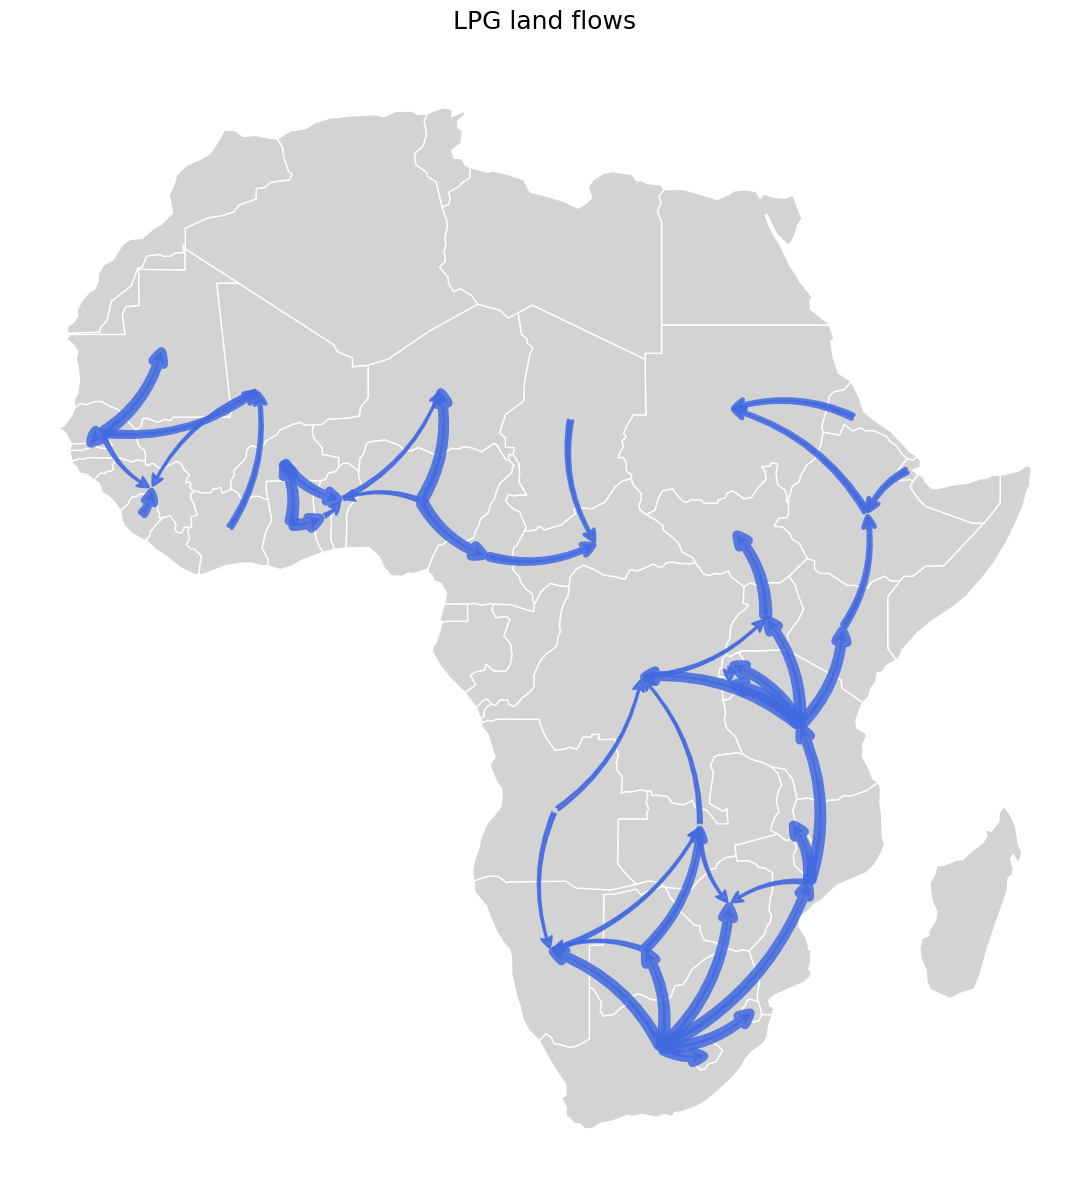

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import tempfile
import urllib.request
import os

# --- 1. Caricamento e Pulizia Dati ---
matrix_file = r'C:/Users/Fra/OneDrive - Politecnico di Milano/File di Mattia Cinchetti - Thesis_onstoveM&F/OnStoveThesis/thesis/script_nostri/dataset_first_step/border_points_matrix.csv'

# Carichiamo la matrice: index_col=0 legge la prima colonna come indice
df_matrix = pd.read_csv(matrix_file, index_col=0)
# Rinominiamo l'indice (cella A1 vuota nel CSV) per coerenza con il codice
df_matrix.index.name = 'from_iso3'
df_matrix = df_matrix.reset_index()

# Trasformiamo in formato lungo
df_flows = df_matrix.melt(
    id_vars=['from_iso3'],
    var_name='to_iso3',
    value_name='percentage_2023'
)

# Pulizia dati numerici e stringhe
df_flows['percentage_2023'] = pd.to_numeric(df_flows['percentage_2023'], errors='coerce').fillna(0)
df_flows['from_iso3'] = df_flows['from_iso3'].astype(str).str.strip().str.upper()
df_flows['to_iso3'] = df_flows['to_iso3'].astype(str).str.strip().str.upper()

# Filtriamo flussi maggiori di 0 ed escludiamo auto-flussi
df_flows = df_flows[
    (df_flows['percentage_2023'] > 0) & 
    (df_flows['from_iso3'] != df_flows['to_iso3'])
].copy()

# --- 2. Preparazione Geografica Corretta ---
url_mappa = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

with tempfile.TemporaryDirectory() as tmpdir:
    zip_path = os.path.join(tmpdir, "mappa.zip")
    urllib.request.urlretrieve(url_mappa, zip_path)
    world_gdf = gpd.read_file(f"zip://{zip_path}")

world_gdf.columns = world_gdf.columns.str.lower()
if 'adm0_a3' in world_gdf.columns and 'iso_a3' not in world_gdf.columns:
    world_gdf = world_gdf.rename(columns={'adm0_a3': 'iso_a3'})
elif 'iso_a3_eh' in world_gdf.columns and 'iso_a3' not in world_gdf.columns:
    world_gdf = world_gdf.rename(columns={'iso_a3_eh': 'iso_a3'})

world_gdf['iso_a3'] = world_gdf['iso_a3'].astype(str).str.strip().str.upper()
africa_gdf = world_gdf[world_gdf['continent'] == 'Africa'].copy()

# Calcolo centroidi corretti (Metrici -> Geografici)
africa_gdf_proj = africa_gdf.to_crs(epsg=3857)
centroids_proj = africa_gdf_proj.geometry.centroid
centroids_geo = centroids_proj.to_crs(africa_gdf.crs)

africa_gdf['centroid_x'] = centroids_geo.x
africa_gdf['centroid_y'] = centroids_geo.y

country_centroids = dict(zip(africa_gdf['iso_a3'], zip(africa_gdf['centroid_x'], africa_gdf['centroid_y'])))

# --- 3. Disegno della Mappa ---
fig, ax = plt.subplots(figsize=(12, 12))
africa_gdf.plot(ax=ax, color='lightgray', edgecolor='white', zorder=1)
ax.axis('off')

frecce_disegnate = 0

for index, row in df_flows.iterrows():
    from_iso = row['from_iso3']
    to_iso = row['to_iso3']
    perc = row['percentage_2023']
    
    if from_iso in country_centroids and to_iso in country_centroids:
        start_lon, start_lat = country_centroids[from_iso]
        end_lon, end_lat = country_centroids[to_iso]
        
        linewidth = max(1.5, perc / 15)
        color = 'royalblue'
        
        ax.annotate(
            "", 
            xy=(end_lon, end_lat), 
            xytext=(start_lon, start_lat),
            arrowprops=dict(
                arrowstyle="fancy,head_length=0.8,head_width=0.8,tail_width=0.3", 
                color=color, 
                linewidth=linewidth,
                alpha=0.85,
                connectionstyle="arc3,rad=0.2" 
            ),
            zorder=5 
        )
        frecce_disegnate += 1

print(f"Successo: disegnate {frecce_disegnate} frecce sulla mappa.")
plt.title("LPG land flows", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

# aggiungi attributo percentage ai borders

In [9]:
import pandas as pd
import geopandas as gpd

# --- 1. Configurazione Percorsi ---
matrix_path = r'C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step\border_points_matrix.csv'
gpkg_path = r'C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\dataset_first_step\default.gpkg'

# --- 2. Caricamento e Trasformazione Matrice ---
df_matrix = pd.read_csv(matrix_path, index_col=0)
df_matrix.index.name = 'exporter'
df_matrix = df_matrix.reset_index()

df_long = df_matrix.melt(id_vars='exporter', var_name='importer', value_name='flow_pct')
df_long['flow_pct'] = pd.to_numeric(df_long['flow_pct'], errors='coerce').fillna(0)

matrix_pairs = {}
for _, row in df_long[df_long['flow_pct'] > 0].iterrows():
    pair = (str(row['exporter']).upper(), str(row['importer']).upper())
    matrix_pairs[pair] = row['flow_pct']

# --- 3. Caricamento Layer Geografico ---
gdf_bp = gpd.read_file(gpkg_path, layer='border_points')

geo_pairs = set()
for _, row in gdf_bp.iterrows():
    iso_a = str(row['from_iso3']).upper()
    iso_b = str(row['to_iso3']).upper()
    geo_pairs.add(tuple(sorted((iso_a, iso_b))))

# --- 4. Controllo Discrepanze ---
print("--- ANALISI COERENZA DATI ---")
missing_points = [p for p in matrix_pairs if tuple(sorted(p)) not in geo_pairs]
if missing_points:
    print(f"\n[ATTENZIONE] Coppie in Matrix senza punti di confine ({len(missing_points)}):")
    for p in sorted(missing_points):
        print(f"  - Exporter: {p[0]} -> Importer: {p[1]} | Flow: {matrix_pairs[p]:.2f}%")

unused_borders = [p for p in geo_pairs if (p[0], p[1]) not in matrix_pairs and (p[1], p[0]) not in matrix_pairs]
if unused_borders:
    print(f"\n[INFO] Punti di confine senza flussi in Matrix ({len(unused_borders)}):")
    for p in sorted(unused_borders):
        print(f"  - Confine: {p[0]} - {p[1]}")
print("\n----------------------------\n")

# --- 5. Orientamento e Calcolo Pesi ---
def process_border_point(row):
    iso_a = str(row['from_iso3']).upper()
    iso_b = str(row['to_iso3']).upper()
    
    if (iso_b, iso_a) in matrix_pairs:
        exporter, importer = iso_b, iso_a
    else:
        exporter, importer = iso_a, iso_b
    
    osbp_val = str(row.get('osbp', '')).lower()
    weight = 2 if osbp_val == 'true' else 1
    return pd.Series([exporter, importer, weight])

gdf_bp[['from_iso3', 'to_iso3', 'point_weight']] = gdf_bp.apply(process_border_point, axis=1)

pair_weights = gdf_bp.groupby(['from_iso3', 'to_iso3'])['point_weight'].sum().reset_index()
pair_weights = pair_weights.rename(columns={'point_weight': 'total_pair_weight'})

gdf_bp = gdf_bp.merge(pair_weights, on=['from_iso3', 'to_iso3'], how='left')

def calculate_final_percentage(row):
    key = (row['from_iso3'], row['to_iso3'])
    total_flow = matrix_pairs.get(key, 0)
    if total_flow == 0 or row['total_pair_weight'] == 0:
        return 0.0
    return total_flow * (row['point_weight'] / row['total_pair_weight'])

gdf_bp['percentage_importer'] = gdf_bp.apply(calculate_final_percentage, axis=1)

# --- 6. Salvataggio (Sovrascrittura Layer) ---
cols_to_keep = [c for c in gdf_bp.columns if c not in ['point_weight', 'total_pair_weight']]

# layer='border_points' e engine='pyogrio' con append=False sovrascrivono il layer specifico
gdf_bp[cols_to_keep].to_file(
    gpkg_path, 
    layer='border_points', 
    driver="GPKG", 
    engine="pyogrio"
)

print(f"Processo completato. Layer 'border_points' aggiornato in: {gpkg_path}")

--- ANALISI COERENZA DATI ---

[INFO] Punti di confine senza flussi in Matrix (34):
  - Confine: AGO - COG
  - Confine: AGO - ZMB
  - Confine: BFA - CIV
  - Confine: BFA - MLI
  - Confine: BFA - NER
  - Confine: BFA - TGO
  - Confine: BWA - ZWE
  - Confine: CIV - GHA
  - Confine: CIV - GIN
  - Confine: CIV - LBR
  - Confine: CMR - COG
  - Confine: CMR - GAB
  - Confine: CMR - GNQ
  - Confine: CMR - TCD
  - Confine: COD - COG
  - Confine: COD - RWA
  - Confine: COG - DRC
  - Confine: COG - GAB
  - Confine: DJI - ERI
  - Confine: DJI - SOM
  - Confine: ERI - ETH
  - Confine: ESH - MRT
  - Confine: ETH - SOM
  - Confine: GAB - GNQ
  - Confine: GIN - LBR
  - Confine: GNB - SEN
  - Confine: KEN - UGA
  - Confine: MLI - NER
  - Confine: MOZ - SWZ
  - Confine: MOZ - ZMB
  - Confine: MWI - TZA
  - Confine: MWI - ZMB
  - Confine: RWA - UGA
  - Confine: TZA - ZMB

----------------------------

Processo completato. Layer 'border_points' aggiornato in: C:\Users\Fra\OneDrive - Politecnico di Milano